Successfully loaded 'china_gdp.csv'.

Dataset head:
   Year         Value
0  1960  5.918412e+10
1  1961  4.955705e+10
2  1962  4.668518e+10
3  1963  5.009730e+10
4  1964  5.906225e+10

Fitted parameters: Beta_1=18.8694, Beta_2=0.8967

--- Model Evaluation ---
R-squared (R^2) value: 0.9756

Saved plot: 'actual_vs_predicted_gdp.png'


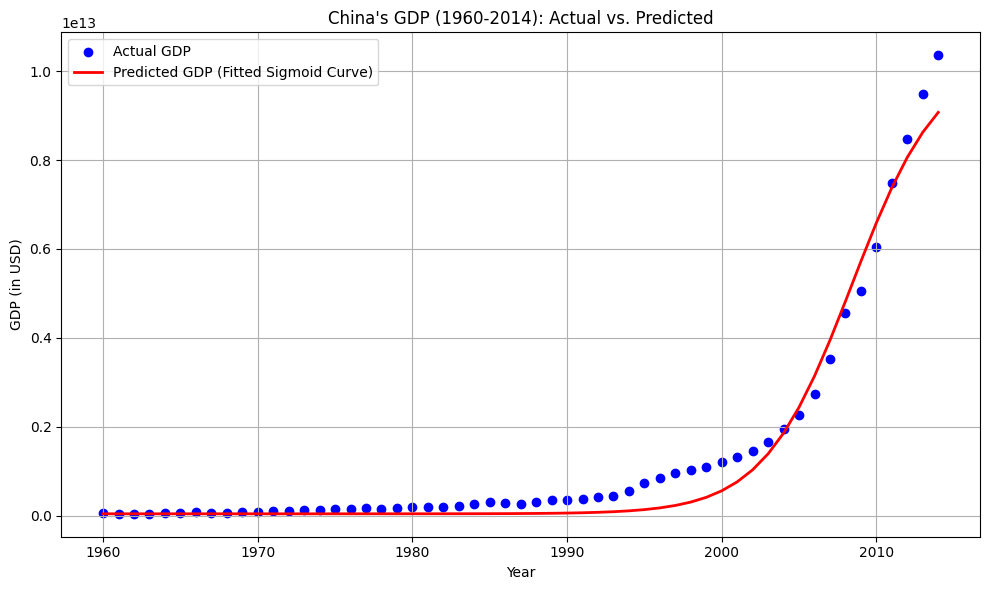

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

try:
    df = pd.read_csv('china_gdp.csv')
    print("Successfully loaded 'china_gdp.csv'.")
except FileNotFoundError:
    print("Error: 'china_gdp.csv' not found.")
    print("Creating sample data that follows a sigmoid curve to proceed.")
    years = np.arange(1960, 2015)
    gdp_start = 5.97E+10
    gdp_end = 1.048E+13

    x_sample = (years - 1960) / (2014 - 1960)
    beta_1_sample = 5.0
    beta_2_sample = 0.7

    y_sample_norm = 1 / (1 + np.exp(-beta_1_sample * (x_sample - beta_2_sample)))

    gdp = y_sample_norm * (gdp_end - gdp_start) + gdp_start

    noise = np.random.normal(0, 0.02, size=len(years))
    gdp = gdp * (1 + noise)

    df = pd.DataFrame({'Year': years, 'Value': gdp})

print("\nDataset head:")
print(df.head())

if 'Year' not in df.columns or 'Value' not in df.columns:
    print("\nError: The dataset must contain 'Year' and 'Value' columns.")
else:
    x_data_orig = df['Year'].values
    y_data_orig = df['Value'].values

    x_min, x_max = np.min(x_data_orig), np.max(x_data_orig)
    y_min, y_max = np.min(y_data_orig), np.max(y_data_orig)

    x_data_norm = (x_data_orig - x_min) / (x_max - x_min)
    y_data_norm = (y_data_orig - y_min) / (y_max - y_min)

    def sigmoid(x, Beta_1, Beta_2):
        """
        A simple logistic (sigmoid) function.
        Beta_1 controls the steepness of the curve.
        Beta_2 controls the x-position of the inflection point.
        """
        y = 1 / (1 + np.exp(-Beta_1 * (x - Beta_2)))
        return y

    try:
        popt, pcov = curve_fit(sigmoid, x_data_norm, y_data_norm)

        print(f"\nFitted parameters: Beta_1={popt[0]:.4f}, Beta_2={popt[1]:.4f}")

        y_pred_norm = sigmoid(x_data_norm, *popt)

        y_pred_orig = y_pred_norm * (y_max - y_min) + y_min

        r2 = r2_score(y_data_orig, y_pred_orig)
        print(f"\n--- Model Evaluation ---")
        print(f"R-squared (R^2) value: {r2:.4f}")

        plt.figure(figsize=(10, 6))

        plt.scatter(x_data_orig, y_data_orig, color='blue', label='Actual GDP')

        plt.plot(x_data_orig, y_pred_orig, color='red', linewidth=2, label='Predicted GDP (Fitted Sigmoid Curve)')

        plt.title("China's GDP (1960-2014): Actual vs. Predicted")
        plt.xlabel('Year')
        plt.ylabel('GDP (in USD)')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        plt.savefig('actual_vs_predicted_gdp.png')
        print("\nSaved plot: 'actual_vs_predicted_gdp.png'")

    except RuntimeError:
        print("\nError: The non-linear regression (curve_fit) failed to converge.")
    except Exception as e:
        print(f"\nAn unexpected error occurred: {e}")